# Manufacturing Productivity and Downtime Analysis
**Applying Six Sigma and Lean Waste Frameworks**

## I. Executive Summary

### Current State

The bottled drink facility presents significant inefficiencies regarding the manufacturing process. A great deal of downtime is due to Non Added Value activities which results in reduced productivity, idle time and profit loss. The manufacturing facility is currently functioning bellow typical industry standards, OEE being severely affected by downtime.

### Key Findings

- Downtime increases with production runtime, hence operational conditions are the cause of production losses, not isolated events
- Operator performance is even, suggesting consistent competence across the workforce
- The two largest downtime contributors, Machine Failure and Inventory Shortage, make up for 40% of total downtime and are largely unrelated to operator actions
- Waiting and Defects are the dominant Lean Waste categories, both in frequency and total time lost
- More data would allow for a deeper more accurate analysis

### Biggest opportunity

The biggest opportunity for improvement lies in reducing unplanned downtime caused by Machine Failures and Inventory Shortages, through implementing autonomous maintenance programs, preventive maintenance scheduling, improved inventory forecasting, and strategic buffer stock management. By targeting these factors, the facility can significantly improve OEE, reduce operational waste, increase productive capacity, and recover a substantial portion of the more than one-third of operating time currently not generating value.




## II. Introduction

This project presents a deep analysis into a Bottled Drink Manufacturing Facility's performance based on productivity and downtime data. The main objectives are to identify the main drivers of productivity and quality loss, quantify downtime and operational waste, and later provide data-driven recommendations according to Six Sigma and Lean Manufacturing methodologies.

The analysis combines:
- Production data
- Downtime data
- Exploratory Data Analysis (EDA)
- Statistical Analysis
- Root-Cause(s) Assessment and Lean Waste Categorization
- Pareto Analysis
- One-Way ANOVA
- Statistical Process Control (SPC)
- Overall Equipment Efficiency (OEE)


Enabling to identify:
- Major sources of productivity loss
- Dominant Wastes
- Product and/or Operator specific performance issues
- Operational and Efficiency Status-quo
- Opportunities for Process Improvement




## III. The Dataset

The dataset is called [“Manufacturing Efficiency in Downtime Operations”](https://www.kaggle.com/datasets/agungpambudi/predict-manufacturing-downtime-performance-dataset?select=downtime-factors.csv), available on kaggle.

**line-productivity.csv** - Fact table containing details for each batch produced
- Date: Date the batch was produced
- Product: ID for the product in the batch
- Batch: Unique ID for the batch produced
- Operator: Production line operator in charge of the batch
- Start Time: Time the batch production started
- End Time: Time the batch production ended

**products.csv** - Dimension table with details on each product
- Product: Unique product ID
- Flavor: Soda flavor for the product
- Size: Product size (volume)
- Min batch time: Minimum time required to produce a batch (with no downtime)

**line-downtime.csv** - Fact table containing downtime (in minutes) by factor for each batch
- Batch: Unique ID for the batch produced
- Downtime Factor: Downtime minutes for each factor ID (across columns)

**downtime-factors.csv** - Dimension table with details on each downtime factor
- Factor: Unique ID for each downtime factor
- Description: Downtime factor description
- Operator Error: Is this due to operator error? (Y/N)




# 1. Data Cleaning and Modelling

In [2]:
import numpy as np
import pandas as pd
import datetime as dt
from datetime import timedelta
import re

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Line Productivity Table

In [3]:
line_productivity = pd.read_csv('../data/raw/line-productivity.csv', delimiter='|',index_col=0)
line_productivity.head()

,Product,Batch,Operator,Start Time,End Time
Date,,,,,
2024-08-29,OR-600,422111,Mac,11:50:00,14:05:00
2024-08-29,LE-600,422112,Mac,14:05:00,15:45:00
2024-08-29,LE-600,422113,Mac,15:45:00,17:35:00
2024-08-29,LE-600,422114,Mac,17:35:00,19:15:00
2024-08-29,LE-600,422115,Charlie,19:15:00,20:39:00


In [4]:
# Setting 'Date' as the Index and converting to datetime
line_productivity.index = pd.to_datetime(line_productivity.index)

In [5]:
# Change last value on 'End Time' and remove the 1900s date stamp
line_productivity['End Time'].iloc[-1] = '01:05:00'

In [6]:
line_productivity.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 31 entries, 2024-08-29 to 2024-09-03
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Product     31 non-null     object
 1   Batch       31 non-null     int64 
 2   Operator    31 non-null     object
 3   Start Time  31 non-null     object
 4   End Time    31 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.5+ KB


In [7]:
# Coverting Datatypes
line_productivity['Start Time'] = pd.to_datetime(line_productivity.index.strftime('%Y-%m-%d')+' '+line_productivity['Start Time'])
line_productivity['End Time'] = pd.to_datetime(line_productivity.index.strftime('%Y-%m-%d')+' '+line_productivity['End Time'])

# Let's not forget that the last value goes into AM hours and the day should shift
line_productivity['End Time'].iloc[-1] = line_productivity['End Time'].iloc[-1] + pd.DateOffset(days=1) 
line_productivity.head()

,Product,Batch,Operator,Start Time,End Time
Date,,,,,
2024-08-29,OR-600,422111,Mac,2024-08-29 11:50:00,2024-08-29 14:05:00
2024-08-29,LE-600,422112,Mac,2024-08-29 14:05:00,2024-08-29 15:45:00
2024-08-29,LE-600,422113,Mac,2024-08-29 15:45:00,2024-08-29 17:35:00
2024-08-29,LE-600,422114,Mac,2024-08-29 17:35:00,2024-08-29 19:15:00
2024-08-29,LE-600,422115,Charlie,2024-08-29 19:15:00,2024-08-29 20:39:00


In [8]:
# Doesn't seem like we have much data, and indeed we only have a few weekdays with several shifts, so seasonality analysis and the like won't
# be possible with this dataset

line_productivity['Weekday'] = line_productivity.index.day_name()
line_productivity.Weekday.unique()

array(['Thursday', 'Friday', 'Saturday', 'Monday', 'Tuesday'],
      dtype=object)

In [9]:
# Calculating Cycle Time and Cycle Time in Minutes
line_productivity['Cycle Time'] = line_productivity['End Time'] - line_productivity['Start Time']
line_productivity['Cycle Time'] = line_productivity['Cycle Time'].dt.total_seconds().div(60).astype(int)
line_productivity.head()

,Product,Batch,Operator,Start Time,End Time,Weekday,Cycle Time
Date,,,,,,,
2024-08-29,OR-600,422111,Mac,2024-08-29 11:50:00,2024-08-29 14:05:00,Thursday,135
2024-08-29,LE-600,422112,Mac,2024-08-29 14:05:00,2024-08-29 15:45:00,Thursday,100
2024-08-29,LE-600,422113,Mac,2024-08-29 15:45:00,2024-08-29 17:35:00,Thursday,110
2024-08-29,LE-600,422114,Mac,2024-08-29 17:35:00,2024-08-29 19:15:00,Thursday,100
2024-08-29,LE-600,422115,Charlie,2024-08-29 19:15:00,2024-08-29 20:39:00,Thursday,84


**Products Table**

In [10]:
products = pd.read_csv('../data/raw/products.csv', delimiter='|')
products['Product Name'] = products.Flavor + ' ' + products.Size
products

,Product,Flavor,Size,Min batch time,Product Name
0,OR-600,Orange,600 ml,60,Orange 600 ml
1,LE-600,Lemon lime,600 ml,60,Lemon lime 600 ml
2,CO-600,Cola,600 ml,60,Cola 600 ml
3,DC-600,Diet Cola,600 ml,60,Diet Cola 600 ml
4,CO-2L,Cola,2 L,98,Cola 2 L


In [11]:
line_productivity = pd.merge(line_productivity, products[['Product','Min batch time','Product Name']], left_on='Product',right_on='Product',how='left')

In [12]:
line_productivity['Total Downtime'] = line_productivity['Cycle Time'] - line_productivity['Min batch time']

In [13]:
line_productivity.head()

,Product,Batch,Operator,Start Time,End Time,Weekday,Cycle Time,Min batch time,Product Name,Total Downtime
0,OR-600,422111,Mac,2024-08-29 11:50:00,2024-08-29 14:05:00,Thursday,135,60,Orange 600 ml,75
1,LE-600,422112,Mac,2024-08-29 14:05:00,2024-08-29 15:45:00,Thursday,100,60,Lemon lime 600 ml,40
2,LE-600,422113,Mac,2024-08-29 15:45:00,2024-08-29 17:35:00,Thursday,110,60,Lemon lime 600 ml,50
3,LE-600,422114,Mac,2024-08-29 17:35:00,2024-08-29 19:15:00,Thursday,100,60,Lemon lime 600 ml,40
4,LE-600,422115,Charlie,2024-08-29 19:15:00,2024-08-29 20:39:00,Thursday,84,60,Lemon lime 600 ml,24


### Line Downtime Table

In [14]:
line_downtime = pd.read_csv('../data/raw/line-downtime.csv', delimiter = '|', index_col = 0)
line_downtime.head()

,Factor 1,2,3,4,5,6,7,8,9,10,11,12
Batch,,,,,,,,,,,,
Batch,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN
422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
line_downtime = line_downtime.rename(columns=line_downtime.iloc[0])  # set first row as header
line_downtime = line_downtime[1:]                         # remove row
line_downtime = line_downtime.reset_index()               # set 'Batch' as its own column

# Cleaning up the Column names
cols = line_downtime.columns.values.astype(str)
new_cols = [re.split(r'[.]', item)[0] for item in cols]
line_downtime.columns = new_cols
line_downtime.head()

,Batch,1,2,3,4,5,6,7,8,9,10,11,12
0,422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN
1,422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
2,422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN
4,422115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN


In [16]:
# Get downtime per Batch
line_downtime['Downtime Frequency']=(line_downtime.count(axis=1))-1
line_downtime['Total Downtime']=line_downtime.loc[:,'1':'12'].sum(axis=1, skipna =True, numeric_only=True)
line_downtime.head()

,Batch,1,2,3,4,5,6,7,8,9,10,11,12,Downtime Frequency,Total Downtime
0,422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,2,75.0
1,422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN,2,40.0
2,422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,50.0
3,422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,2,40.0
4,422115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN,1,24.0


Here we can compare the total downtime with the downtime from the previous line productivity table and check that the values are the same.

In [17]:
# Converting datatypes
line_downtime.Batch = line_downtime.Batch.astype(int)
line_downtime = line_downtime.drop(line_downtime[(line_downtime.Batch > 422136) & (line_downtime.Batch < 422144)].index) # removing downtime with no other production data
line_downtime = line_downtime.fillna(0)
line_downtime.head()

,Batch,1,2,3,4,5,6,7,8,9,10,11,12,Downtime Frequency,Total Downtime
0,422111,0.0,60.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,2,75.0
1,422112,0.0,20.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,2,40.0
2,422113,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,50.0
3,422114,0.0,0.0,0.0,25.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,2,40.0
4,422115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,1,24.0


In [18]:
line_productivity = pd.merge(line_productivity, line_downtime[['Batch','Downtime Frequency']], left_on='Batch', right_on='Batch', how='left') 
line_productivity

,Product,Batch,Operator,Start Time,End Time,Weekday,Cycle Time,Min batch time,Product Name,Total Downtime,Downtime Frequency
0,OR-600,422111,Mac,2024-08-29 11:50:00,2024-08-29 14:05:00,Thursday,135,60,Orange 600 ml,75,2
1,LE-600,422112,Mac,2024-08-29 14:05:00,2024-08-29 15:45:00,Thursday,100,60,Lemon lime 600 ml,40,2
2,LE-600,422113,Mac,2024-08-29 15:45:00,2024-08-29 17:35:00,Thursday,110,60,Lemon lime 600 ml,50,1
3,LE-600,422114,Mac,2024-08-29 17:35:00,2024-08-29 19:15:00,Thursday,100,60,Lemon lime 600 ml,40,2
4,LE-600,422115,Charlie,2024-08-29 19:15:00,2024-08-29 20:39:00,Thursday,84,60,Lemon lime 600 ml,24,1
5,LE-600,422116,Charlie,2024-08-29 20:39:00,2024-08-29 21:39:00,Thursday,60,60,Lemon lime 600 ml,0,0
6,LE-600,422117,Charlie,2024-08-29 21:39:00,2024-08-29 22:54:00,Thursday,75,60,Lemon lime 600 ml,15,2
7,CO-600,422118,Dee,2024-08-30 04:05:00,2024-08-30 06:05:00,Friday,120,60,Cola 600 ml,60,4
8,CO-600,422119,Dee,2024-08-30 06:05:00,2024-08-30 07:30:00,Friday,85,60,Cola 600 ml,25,1
9,CO-600,422120,Dee,2024-08-30 07:30:00,2024-08-30 09:22:00,Friday,112,60,Cola 600 ml,52,3


### Unpivoted Line Downtime Table

In [19]:
unpivoted_downtime = pd.melt(line_downtime[['Batch', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']], id_vars='Batch', var_name='Factor', value_name='Downtime')
unpivoted_downtime.Factor = unpivoted_downtime.Factor.astype(int)
unpivoted_downtime.sort_values(['Batch','Factor'],ascending=[True,True]).head()

,Batch,Factor,Downtime
0,422111,1,0.0
31,422111,2,60.0
62,422111,3,0.0
93,422111,4,0.0
124,422111,5,0.0


**Factors Table**

In [20]:
factors = pd.read_csv('../data/raw/downtime-factors.csv', delimiter='|')
factors.Factor = factors.Factor.astype(int)
factors

,Factor,Description,Operator Error
0,1,Emergency stop,No
1,2,Batch change,Yes
2,3,Labeling error,No
3,4,Inventory shortage,No
4,5,Product spill,Yes
5,6,Machine adjustment,Yes
6,7,Machine failure,No
7,8,Batch coding error,Yes
8,9,Conveyor belt jam,No
9,10,Calibration error,Yes


In [21]:
unpivoted_downtime = pd.merge(unpivoted_downtime, factors[['Factor','Description','Operator Error']], left_on='Factor', right_on='Factor', how='left')

In [22]:
unpivoted_downtime.sort_values(['Batch','Factor'],ascending=[True,True]).head()

,Batch,Factor,Downtime,Description,Operator Error
0,422111,1,0.0,Emergency stop,No
31,422111,2,60.0,Batch change,Yes
62,422111,3,0.0,Labeling error,No
93,422111,4,0.0,Inventory shortage,No
124,422111,5,0.0,Product spill,Yes


In [23]:
unpivoted_factor = (unpivoted_downtime.groupby(["Factor"])["Downtime"].agg(Total_Downtime='sum').reset_index())
unpivoted_factor = pd.merge(unpivoted_factor , factors, left_on='Factor', right_on='Factor', how='left')
unpivoted_factor.sort_values('Total_Downtime', ascending=False).head()

,Factor,Total_Downtime,Description,Operator Error
6,7,236.0,Machine failure,No
3,4,205.0,Inventory shortage,No
5,6,197.0,Machine adjustment,Yes
1,2,160.0,Batch change,Yes
7,8,115.0,Batch coding error,Yes


In [24]:
sum_of_downtime_m = unpivoted_factor.Total_Downtime.sum()
unpivoted_factor['Percentage'] = (unpivoted_factor['Total_Downtime']*100)/sum_of_downtime_m
unpivoted_factor.sort_values('Total_Downtime', ascending=False).head()

,Factor,Total_Downtime,Description,Operator Error,Percentage
6,7,236.0,Machine failure,No,20.884956
3,4,205.0,Inventory shortage,No,18.141593
5,6,197.0,Machine adjustment,Yes,17.433628
1,2,160.0,Batch change,Yes,14.159292
7,8,115.0,Batch coding error,Yes,10.176991


**Getting the Frequency per Factor**

In [25]:
count_col = line_downtime[line_downtime != 0].count(axis=0).iloc[1:13].to_frame(name='Downtime Frequency')
unpivoted_factor['Downtime_Count'] = count_col['Downtime Frequency'].values
unpivoted_factor.sort_values('Total_Downtime', ascending=False).head()

,Factor,Total_Downtime,Description,Operator Error,Percentage,Downtime_Count
6,7,236.0,Machine failure,No,20.884956,10
3,4,205.0,Inventory shortage,No,18.141593,8
5,6,197.0,Machine adjustment,Yes,17.433628,8
1,2,160.0,Batch change,Yes,14.159292,5
7,8,115.0,Batch coding error,Yes,10.176991,5


**Lean Manufacturing 8 Wastes**

The Lean Manufacturing 8 Wastes sorts various kinds of downtime factors into different types of waste:

- D: defects
- O: overproduction
- W: waiting
- N: non-utilized talend or skills
- T: transportation
- I: inventory
- M: motion
- E: extra-processing
  
It allows to transform a myriad of downtime factors into structured, actionable items.
We can later apply the Paretto principle and decide where to spend money tackling the most pressing issues.

In [26]:
# Sorting the Factors according to the 8 Wastes Framework, only primary waste type considered for simplicity
wastes = ['Waiting','Waiting','Defects','Inventory','Defects','Extra-Processing','Waiting','Defects','Waiting','Defects','Defects','Undefined']

unpivoted_factor['Waste Type'] = wastes
unpivoted_factor.sort_values('Total_Downtime', ascending=False)

,Factor,Total_Downtime,Description,Operator Error,Percentage,Downtime_Count,Waste Type
6,7,236.0,Machine failure,No,20.884956,10,Waiting
3,4,205.0,Inventory shortage,No,18.141593,8,Inventory
5,6,197.0,Machine adjustment,Yes,17.433628,8,Extra-Processing
1,2,160.0,Batch change,Yes,14.159292,5,Waiting
7,8,115.0,Batch coding error,Yes,10.176991,5,Defects
11,12,67.0,Other,No,5.929204,5,Undefined
4,5,57.0,Product spill,Yes,5.044248,3,Defects
9,10,34.0,Calibration error,Yes,3.008850,2,Defects
2,3,22.0,Labeling error,No,1.946903,1,Defects
10,11,20.0,Label switch,Yes,1.769912,2,Defects


In [27]:
waste_frequency = unpivoted_factor.groupby('Waste Type')['Downtime_Count'].sum().sort_values(ascending=False)
waste_frequency = waste_frequency.to_frame()

In [28]:
time_per_waste = unpivoted_factor.groupby('Waste Type')['Total_Downtime'].sum().sort_values(ascending=False)
time_per_waste = time_per_waste.to_frame()
time_per_waste['Percentage'] = (time_per_waste['Total_Downtime']*100)/sum_of_downtime_m

In [29]:
total_waste = pd.merge(waste_frequency, time_per_waste, left_on='Waste Type', right_on='Waste Type', how='left')
total_waste = total_waste.rename(columns={'Downtime_Count':'Frequency','Total_Downtime': 'Minutes'})
total_waste.sort_values('Percentage',ascending=False)

,Frequency,Minutes,Percentage
Waste Type,,,
Waiting,16,413.0,36.548673
Defects,13,248.0,21.946903
Inventory,8,205.0,18.141593
Extra-Processing,8,197.0,17.433628
Undefined,5,67.0,5.929204


# 2. Exploratory Data Analysis

## 2.1. Temporal and Shift Analysis

Can we get a better view of the shifts across time, what was produced and by whom? - Yes.

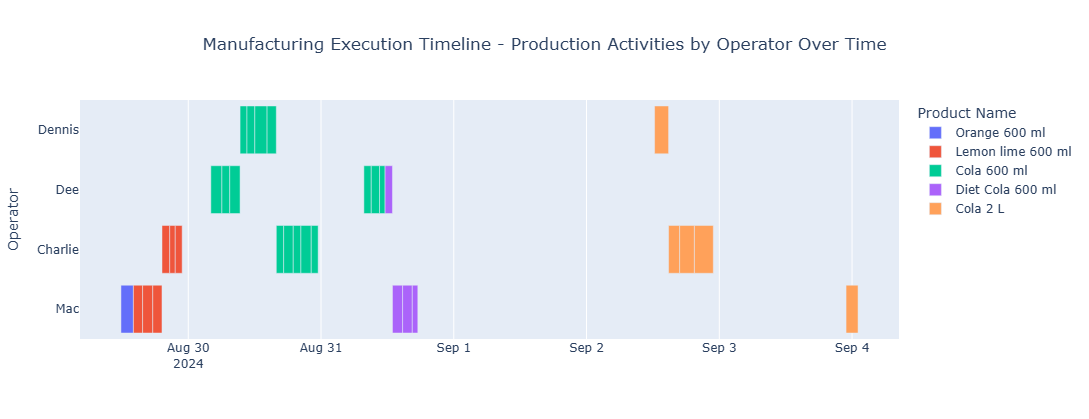

In [67]:
fig = px.timeline(line_productivity, x_start = "Start Time", x_end = "End Time", y = "Operator",
                  color = "Product Name", title='Manufacturing Execution Timeline - Production Activities by Operator Over Time')
fig.update_layout(title_x=0.5, width=1100, height=400)
fig.show()

We can see that there is only one worker per batch or use the following snippet:

> `worker_count = (lp.groupby("Batch")["Operator"].nunique().reset_index(name='NumWorkers'))`

The shifts are very irregular, both in time, duration, operator...
There are batches we have the downtime data for, but no other production data - these coincide with times between Saturday and Monday. Could the missing data be related to turning off/on certain systems or neglecting procedures related to data collection by shutting down the production line for the Sunday / taking time to restart on Monday?

**Total Time Production - Sum of Cycle Times**

What is the total cycle time / time of production given in this dataset?

In [31]:
total_cycle_time = line_productivity['Cycle Time'].sum()
total_cycle_time_h = total_cycle_time/60

print("Total Time Production: ", total_cycle_time)
print("Total Time Production(h): ", total_cycle_time_h)

Total Time Production:  3180
Total Time Production(h):  53.0


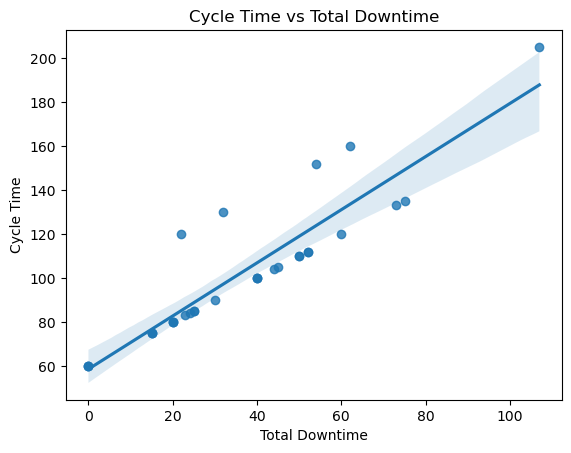

In [32]:
sns.regplot(
    data=line_productivity,
    x='Total Downtime',
    y='Cycle Time'
)

plt.title('Cycle Time vs Total Downtime')
plt.show()
plt.show()

As donwtime increases, so does cycle time, as expected. No other anomalies. The 5 seemingly outliers correspond to the 5 batches of Cola 2L produced, the regression line would fit perfectly if it were excluded, as these batches take more time to produce.

## 2.2 Batch

### 2.2.1 Batch - Production

How many batches were produced by day?

In [33]:
# Extract date
line_productivity["Date"] = line_productivity["Start Time"].dt.date

batches_per_day = line_productivity.groupby(["Date", "Weekday"]).agg(Batch_Count=("Batch", "nunique")).reset_index()
weekday_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
batches_per_day["Weekday"] = pd.Categorical(batches_per_day["Weekday"],categories=weekday_order,ordered=True)
batches_per_day = batches_per_day.sort_values("Date")

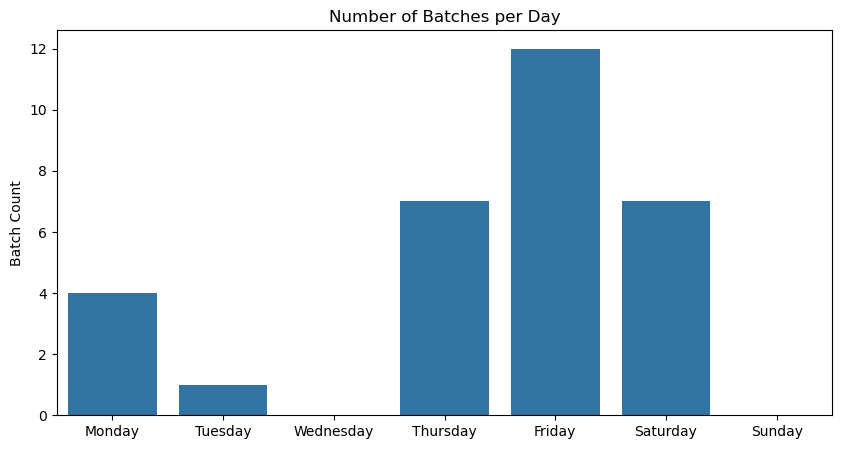

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(data=batches_per_day,x="Weekday",y="Batch_Count",order=weekday_order)
plt.title("Number of Batches per Day")
plt.ylabel("Batch Count")
plt.xlabel("")
plt.show()

In [35]:
time_trend = line_productivity.groupby('Date')[['Total Downtime','Cycle Time']].sum()
time_trend['Percentage'] = (time_trend['Total Downtime']*100)/time_trend['Cycle Time']
time_trend

,Total Downtime,Cycle Time,Percentage
Date,,,
2024-08-29,244,664,36.746988
2024-08-30,444,1164,38.144330
2024-08-31,165,585,28.205128
2024-09-02,245,637,38.461538
2024-09-03,32,130,24.615385


The data indicates there isn't any improvement nor degradation trend, although these ratios are high for production standards.

### 2.2.1 Batch - Downtime

How can we quickly see the biggest downtime culprit? - Heatmap.

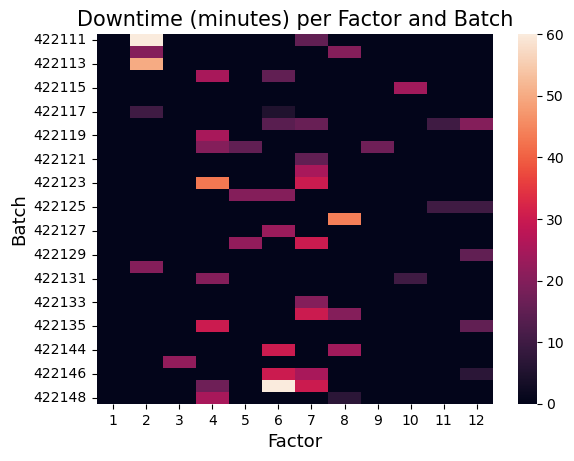

In [36]:
factor_batch_heatmap = line_downtime[['Batch', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']]
factor_batch_heatmap = factor_batch_heatmap.set_index("Batch")

ax = sns.heatmap(factor_batch_heatmap) 

plt.title('Downtime (minutes) per Factor and Batch', fontsize = 15) 
plt.xlabel('Factor', fontsize = 13) 
plt.ylabel('Batch', fontsize = 13) 

plt.show()

The Factors that contribute the most to downtime are 7, 6, 4 and 2.


Which Batch production has the highest downtime value?

In [37]:
print("Highest downtime per Batch: ",line_productivity['Total Downtime'].max())
line_productivity[['Batch','Total Downtime']].sort_values('Total Downtime', ascending=False).head()

Highest downtime per Batch:  107


,Batch,Total Downtime
29,422147,107
0,422111,75
12,422123,73
28,422146,62
7,422118,60


## 2.3. Product

### 2.3.1. Product - Production 

**Total Cycle Time - Product**

How much of this time was spent on each product? How many were produced?

In [38]:
product_cycle_time = line_productivity.groupby("Product Name", as_index=False).agg({"Cycle Time":"sum","Batch":"nunique"}).rename(columns={"Batch": "Batch Count"})
product_cycle_time['Cycle Time(h)'] = product_cycle_time['Cycle Time'] / 60
product_cycle_time.sort_values('Cycle Time',ascending=False)

,Product Name,Cycle Time,Batch Count,Cycle Time(h)
1,Cola 600 ml,1394,15,23.233333
0,Cola 2 L,767,5,12.783333
3,Lemon lime 600 ml,529,6,8.816667
2,Diet Cola 600 ml,355,4,5.916667
4,Orange 600 ml,135,1,2.250000


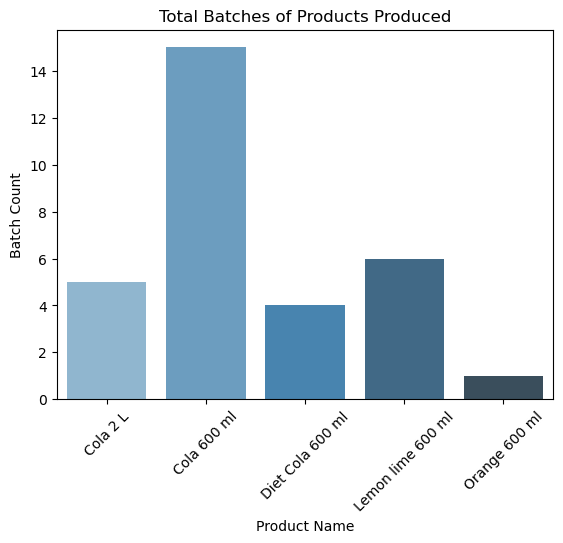

In [39]:
sns.barplot(data=product_cycle_time, x="Product Name", y="Batch Count",palette="Blues_d")
plt.title('Total Batches of Products Produced')
plt.xticks(rotation=45)
plt.show()

**Average Cycle Time - Product**

What was the average cycle time per product? The minimum amount of time it takes to complete is 60 minutes, except for CO-2L, which takes 98 minutes (this would be the ideal scenario, naturally it will always take more as some processes, like preparing gear for another batch, cannot be eliminated, only streamlined). 

In [40]:
product_avg_cycle_time = (
    line_productivity.groupby(["Product Name", "Batch"])["Cycle Time"].sum()
    .groupby("Product Name").mean().reset_index(name="Avg Cycle Time")
)

product_avg_cycle_time['Avg Cycle Time(h)'] = product_avg_cycle_time['Avg Cycle Time'] / 60
product_avg_cycle_time.sort_values('Avg Cycle Time',ascending=False)

,Product Name,Avg Cycle Time,Avg Cycle Time(h)
0,Cola 2 L,153.400000,2.556667
4,Orange 600 ml,135.000000,2.250000
1,Cola 600 ml,92.933333,1.548889
2,Diet Cola 600 ml,88.750000,1.479167
3,Lemon lime 600 ml,88.166667,1.469444


**Production Data - Products**

- In order to observe the distribution of how cycle time duration varies -->  Violinplot.

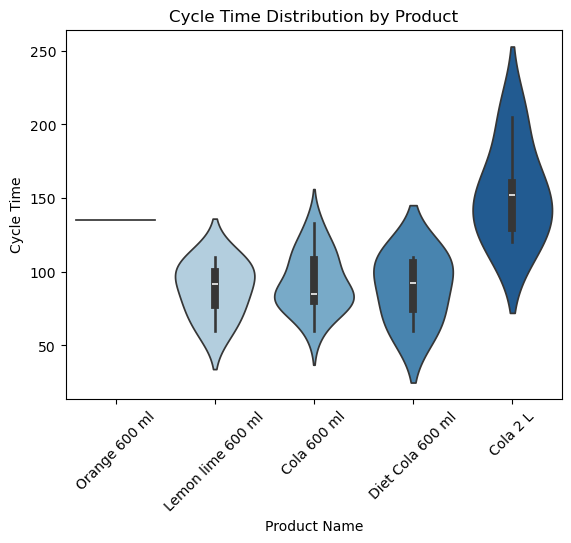

In [41]:
sns.violinplot(x="Product Name", y="Cycle Time", data=line_productivity, palette="Blues")
plt.title('Cycle Time Distribution by Product')
plt.xticks(rotation=45)
plt.show()

We can immediately spot that only one batch of Orange 600ml was produced. The Cola 2L has higher Cycle Time as expected as it is the batch type that takes the most time to finish. Cola 2L and Cola 600ml seem to be the products that managed to stay closer to the minimum cycle time when being produced.

### 2.3.1. Product - Downtime

- How much downtime per Product? How many instances?
- How much space does it take out of the total production time? Orange 600ml is higher than the others, but keep in mind only one Batch was produced.

In [42]:
product_downtime = line_productivity[['Product Name','Total Downtime','Downtime Frequency']].groupby(['Product Name']).sum().sort_values("Total Downtime", ascending=False)
product_downtime['Total Downtime(h)'] = product_downtime['Total Downtime'].apply(lambda x: timedelta(minutes=x))
product_downtime[['Total Downtime','Total Downtime(h)','Downtime Frequency']].sort_values('Total Downtime', ascending=False)

,Total Downtime,Total Downtime(h),Downtime Frequency
Product Name,,,
Cola 600 ml,494,0 days 08:14:00,24
Cola 2 L,277,0 days 04:37:00,11
Lemon lime 600 ml,169,0 days 02:49:00,8
Diet Cola 600 ml,115,0 days 01:55:00,5
Orange 600 ml,75,0 days 01:15:00,2


**Product Production and Downtime Statistics**

In [44]:
product_statistics = line_productivity.groupby('Product Name')[['Cycle Time','Total Downtime']].agg(['count','mean','median','std']).sort_values(('Cycle Time', 'mean'),ascending=False)
product_statistics

Cycle Time                               Total Downtime  \
                       count        mean median        std          count   
Product Name                                                                
Cola 2 L                   5  153.400000  152.0  33.057526              5   
Orange 600 ml              1  135.000000  135.0        NaN              1   
Cola 600 ml               15   92.933333   85.0  19.879877             15   
Diet Cola 600 ml           4   88.750000   92.5  23.228933              4   
Lemon lime 600 ml          6   88.166667   92.0  18.659225              6   

                                                
                        mean median        std  
Product Name                                    
Cola 2 L           55.400000   54.0  33.057526  
Orange 600 ml      75.000000   75.0        NaN  
Cola 600 ml        32.933333   25.0  19.879877  
Diet Cola 600 ml   28.750000   32.5  23.228933  
Lemon lime 600 ml  28.166667   32.0  18.659225

## 2.4. Operator

### 2.4.1 Operator - Production

**Total Hours Production - Operator**

How many hours have the Operators worked so far?

In [45]:
operator_cycle_time = line_productivity.groupby("Operator", as_index=False).agg({"Cycle Time":"sum","Batch":"nunique"}).rename(columns={"Batch": "Batch Count"})
operator_cycle_time['Cycle Time(h)'] = operator_cycle_time['Cycle Time'] / 60
operator_cycle_time.sort_values('Cycle Time',ascending=False)

,Operator,Cycle Time,Batch Count,Cycle Time(h)
0,Charlie,1158,11,19.300000
3,Mac,850,8,14.166667
1,Dee,627,7,10.450000
2,Dennis,545,5,9.083333


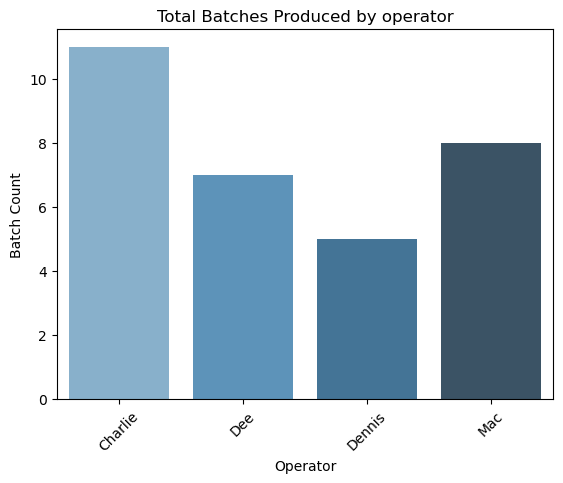

In [46]:
sns.barplot(data=operator_cycle_time, x="Operator", y="Batch Count",palette="Blues_d")
plt.title('Total Batches Produced by operator')
plt.xticks(rotation=45)
plt.show()

### 2.4.2 Operator - Downtime

- How much downtime per Operator? How many instances?
- How much space does it take out of the total production time?

In [47]:
operator_downtime = line_productivity[['Operator','Total Downtime','Downtime Frequency']].groupby(['Operator']).sum().sort_values("Total Downtime", ascending=False)
operator_downtime['Total Downtime(h)'] = operator_downtime['Total Downtime'].apply(lambda x: timedelta(minutes=x))
operator_downtime[['Total Downtime','Total Downtime(h)','Downtime Frequency']].sort_values('Total Downtime', ascending=False)

,Total Downtime,Total Downtime(h),Downtime Frequency
Operator,,,
Charlie,384,0 days 06:24:00,17
Mac,332,0 days 05:32:00,13
Dee,207,0 days 03:27:00,12
Dennis,207,0 days 03:27:00,8


In [49]:
operator_production = pd.merge(operator_downtime, operator_cycle_time, left_on='Operator', right_on='Operator', how='left')
operator_production['Downtime Percentage(%)'] = (operator_production['Total Downtime']*100)/operator_production['Cycle Time']
operator_production.sort_values('Downtime Percentage(%)', ascending=False)

,Operator,Total Downtime,Downtime Frequency,Total Downtime(h),Cycle Time,Batch Count,Cycle Time(h),Downtime Percentage(%)
1,Mac,332,13,0 days 05:32:00,850,8,14.166667,39.058824
3,Dennis,207,8,0 days 03:27:00,545,5,9.083333,37.981651
0,Charlie,384,17,0 days 06:24:00,1158,11,19.300000,33.160622
2,Dee,207,12,0 days 03:27:00,627,7,10.450000,33.014354


**Operator Error Contribution - Human Factor Analysis**

To further explore, the next step is to calculate how many of the downtime instances were 'Operator Error'. The following crosstab table shows which factors are 1. human-driven vs system-driven, and 2. where automation or training matter the most.

In [50]:
pd.crosstab(unpivoted_downtime['Factor'],unpivoted_downtime['Operator Error'],values=unpivoted_downtime['Downtime'],aggfunc='sum').fillna(0)

Operator Error,No,Yes
Factor,,
1,0.0,0.0
2,0.0,160.0
3,22.0,0.0
4,205.0,0.0
5,0.0,57.0
6,0.0,197.0
7,236.0,0.0
8,0.0,115.0
9,17.0,0.0


In [51]:
operator_error_impact = unpivoted_downtime.groupby('Operator Error')['Downtime'].agg(['count', 'sum', 'mean']).sort_values('sum', ascending=False)

operator_error_impact

,count,sum,mean
Operator Error,,,
Yes,186,583.0,3.134409
No,186,547.0,2.940860


In [52]:
operator_error_yes = unpivoted_downtime[unpivoted_downtime["Operator Error"] == "Yes"].groupby('Batch')['Downtime'].sum().reset_index().rename(columns={"Downtime": "Operator Error Downtime"})
operator_error_yes.head()

,Batch,Operator Error Downtime
0,422111,60.0
1,422112,40.0
2,422113,50.0
3,422114,15.0
4,422115,24.0


In [53]:
operator_error_yes = pd.merge(operator_error_yes, line_productivity[['Batch','Operator','Cycle Time']], left_on='Batch', right_on='Batch', how='left')

In [54]:
operator_error_yes = operator_error_yes.groupby('Operator')[['Operator Error Downtime','Cycle Time']].sum().reset_index()
operator_error_yes['Downtime Percentage(%)'] = (operator_error_yes['Operator Error Downtime']*100)/operator_error_yes['Cycle Time']
operator_error_yes.sort_values('Downtime Percentage(%)', ascending=False)

,Operator,Operator Error Downtime,Cycle Time,Downtime Percentage(%)
3,Mac,192.0,850,22.588235
0,Charlie,228.0,1158,19.689119
2,Dennis,94.0,545,17.247706
1,Dee,69.0,627,11.004785


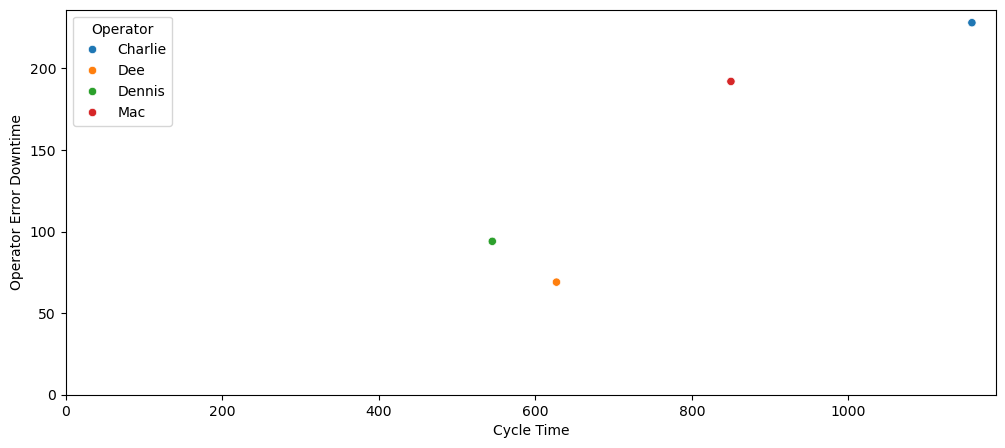

In [55]:
fig, ax = plt.subplots(figsize=(12,5))
sns.scatterplot(data=operator_error_yes,x='Cycle Time',y='Operator Error Downtime',hue='Operator',ax=ax)
ax.set_xlim(0,None)
ax.set_ylim(0,None)
plt.show()

The trend is to accumulate more downtime as you work more hours, yet we can see some variance - could experience/inexperience influence these shifts? Mac has the most downtime relative to worked hours and Dee has the least. This data points out where clearer instructions, training and communication might be needed.

**Operator Production and Downtime Statistics**

In [56]:
operator_statistics = line_productivity.groupby('Operator')[['Cycle Time','Total Downtime']].agg(['count','mean','median','std']).sort_values(('Cycle Time', 'mean'),ascending=False)
operator_statistics

Cycle Time                               Total Downtime             \
              count        mean median        std          count       mean   
Operator                                                                      
Dennis            5  109.000000  100.0  32.549962              5  41.400000   
Mac               8  106.250000  107.5  22.795676              8  41.500000   
Charlie          11  105.272727   84.0  43.213634             11  34.909091   
Dee               7   89.571429   85.0  20.443884              7  29.571429   

                            
         median        std  
Operator                    
Dennis     40.0  23.049946  
Mac        42.5  21.030590  
Charlie    23.0  29.944798  
Dee        25.0  20.443884

# 3. Pareto

## 3.1. Pareto Analysis - Factors

In [57]:
factor_stats = unpivoted_downtime.groupby(['Factor', 'Description','Operator Error'], as_index=False).agg(Downtime=('Downtime', 'sum')).sort_values('Downtime',ascending=False)
total_downtime = factor_stats['Downtime'].sum()
factor_stats['Percentage %'] = (factor_stats['Downtime']*100)/total_downtime
factor_stats['Cumulative %'] = factor_stats['Percentage %'].cumsum()
factor_stats[factor_stats['Cumulative %'] <= 80]

,Factor,Description,Operator Error,Downtime,Percentage %,Cumulative %
6,7,Machine failure,No,236.0,20.884956,20.884956
3,4,Inventory shortage,No,205.0,18.141593,39.026549
5,6,Machine adjustment,Yes,197.0,17.433628,56.460177
1,2,Batch change,Yes,160.0,14.159292,70.619469


The top 5 Factors contribute to 80% of the downtime. The top 2 (40%) are not due to Operator Error, nor required/planned Non Added Value time.

## 3.2. Pareto Analysis - Lean Waste

In [58]:
total_waste['Cumulative %'] = total_waste['Percentage'].cumsum()
total_waste[total_waste['Cumulative %'] <= 80]

,Frequency,Minutes,Percentage,Cumulative %
Waste Type,,,,
Waiting,16,413.0,36.548673,36.548673
Defects,13,248.0,21.946903,58.495575
Extra-Processing,8,197.0,17.433628,75.929204


~60% of Total Downtime is cause by 2 Lean Waste Types: Waiting and Defects.

Waiting is the dominante source of waste, taking up more than a third of Total Donwtime. Delays, idle time, and even inventory shortages that add to secondary waiting, are the major sources of productivity loss. 'Machine Failure' and 'Inventory Shortage' are the top 2 culprits for downtime, both of which result in additional waiting. 

The high percentage of Defects indicate that there are recurring quality issues that result in rework and breaking production flow.

# 4. ANOVA 

## 4.1. One-Way ANOVA

**Does Operator affect Cycle Time?**

Null Hypothesis: All Operators have the same mean cycle time.

In [59]:
from scipy.stats import f_oneway

#Does Operator affect Cycle Time?
groups = [g['Cycle Time'].dropna() for _, g in line_productivity.groupby('Operator')]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 0.489
P-value: 0.6929


With p > 0.05, we fail to reject the null hypothesis.  There is no statistically significant evidence that cycle time differs between operators, indicating consistent performance across personnel.

**Does Product affect Cycle Time?**

Null Hypothesis: All Products have the same mean cycle time.

In [60]:
#Does Product affect Cycle Time?
groups = [
    g['Cycle Time'].dropna()
    for _, g in line_productivity.groupby('Product')
]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 8.513
P-value: 0.0002


With p < 0.05, we reject the null hypothesis, different products different cycle times (checks true, as Cola 2L requires more time).

# 5. Statistical Process Control (SPC)

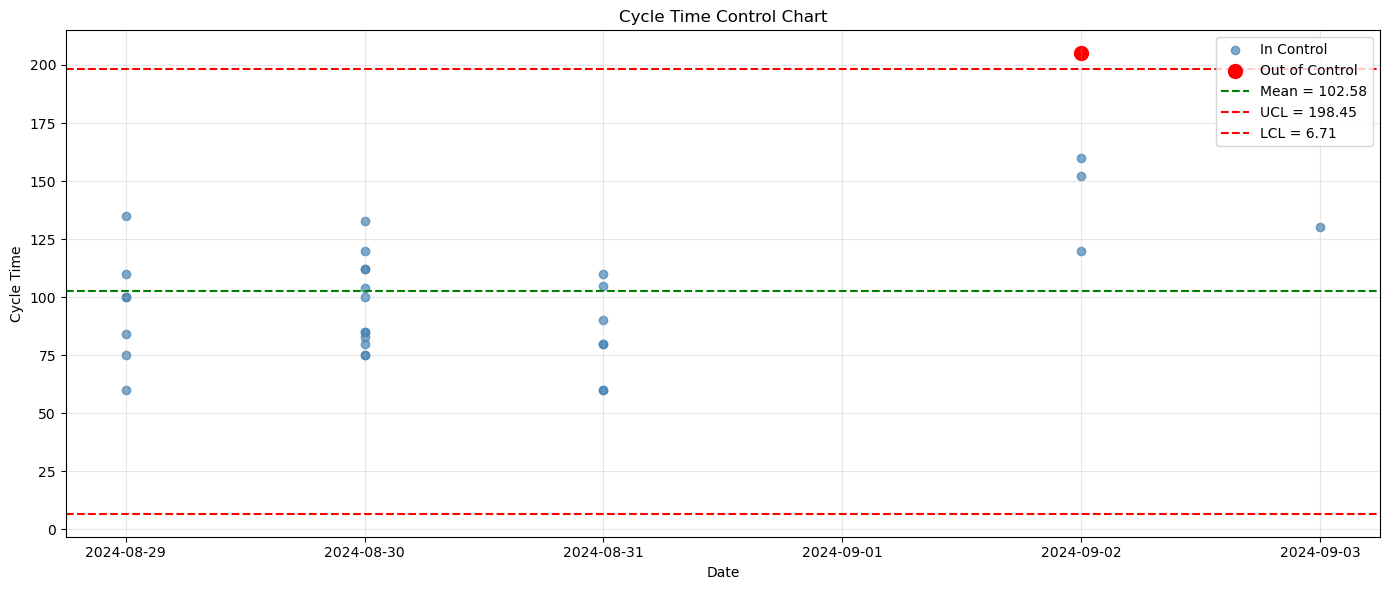

In [61]:
# Limits
mean = line_productivity['Cycle Time'].mean()
std = line_productivity['Cycle Time'].std()
ucl = mean + 3 * std
lcl = mean - 3 * std

# Out-of-control points
out_control = ((line_productivity['Cycle Time'] > ucl) | (line_productivity['Cycle Time'] < lcl))

plt.figure(figsize=(14,6))

# In-control points
plt.scatter(line_productivity.loc[~out_control, 'Date'], line_productivity.loc[~out_control, 'Cycle Time'],
            color='steelblue', alpha=0.7, label='In Control')

# Out-of-control points
plt.scatter(line_productivity.loc[out_control, 'Date'], line_productivity.loc[out_control, 'Cycle Time'], 
            color='red', s=100, label='Out of Control')

# Control lines
plt.axhline(mean, color='green', linestyle='--', label=f'Mean = {mean:.2f}')

plt.axhline(ucl, color='red', linestyle='--', label=f'UCL = {ucl:.2f}')

plt.axhline(lcl, color='red', linestyle='--', label=f'LCL = {lcl:.2f}')

plt.title('Cycle Time Control Chart')
plt.xlabel('Date')
plt.ylabel('Cycle Time')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

- The majority of the points fall within the control limits, showing that the process is generally stable with cycle times within the allowed limits.

- One outlier suggests an isolated incident.

- Cycle times appear spread around the mean, suggesting no strong directional bias in the process.

- Moderate spread between UCL and LCL, suggesting moderate consistency.

# 6. Availability and Overall Equipment Efficiency (OEE)

Given that:
- Operating time is the difference between planned production time and unplanned downtime, and
- Availability is the ratio Between Operating Time and Planned Production Time:

In [62]:
operating_time = total_cycle_time - sum_of_downtime_m
availability = (operating_time / total_cycle_time)*100
print("Operating Time: ", operating_time)
print("Availability: ", availability)

Operating Time:  2050.0
Availability:  64.46540880503144


The Availability is low for industry standards and indicates that over 30% of the time is spent on malfunctions, idle and/or not producing. Production takes up only two-thirds of the time. This suggests that downtime is a significant contributor to capacity loss.

# 7. Conclusions


## On the Data

- The data is scarce, yet provides an acceptable base for performing several analysis and establishing a foundation on what kind of system could be used to gather, process and get insights (were there more data available).
  
- Batches 422137 to 422146 are only present in the downtime table, which would fit between Saturday and Monday: possible data loss due to shutting down / turning on the production line before / after Sunday

- Working Hours and Operators seem random

- Only one Batch is producted at a time

- Only one Operator per Batch


## Findings

- The more time spent producing a Product, the more downtime - no significant anomalies that stand out
  
- The more time spent working by an Operator, the more downtime they experience - no significant anomalies
  
- Product type affects cycle time, as expected
  
- Operator does not affect cycle time significantly, indicating uniform professional skills
  
  

## Recommendations
- Autonomous Maintenance: Train operators to perform simples tasks of machine maintenance and most common repairs,
- Preventive Scheduling: Schedule maintenance based on machine runtime,
  
- Optimize Prep Time by having the necessary gear closer, well stored, having set and clear procedures,
- Apply forecasting systems to better predict inventory shortages - order more material preventively, produce another product instead of being idle
- Keep Buffer Inventory.
  
## Waste and Downtime Factors

-  The top 2 Downtime Factors, Machine Failure and Inventory Shortage (combined total of 40%), are not due to Operator Error, nor required/planned Non Added Value time

- The main Waste Types were determined and the most time consuming and the most frequent coincide
  
- Waiting and Defects are a dangerous combination as waiting creates an urge to rush and catch up with time, which might cause more defects, and defects cause even more waiting due to rework
  

## Next Steps:
- Perform Value Stream Mapping to audit the entire production process
  
- Cross-Training employees so that they can have more autonomy and allocate their time to solving the most pressing bottleneck
  
- Optimize data logging system to obtain more data and more detailed analysis is possible

  


***Overall, the downtime is too high for what would be considered average or acceptable in the manufacturing industry and it is critical to improve OEE***



### **Business Impact:** Over a third of total time is not generating profit.

By prioritizing Downtime Reduction and Lean Waste elimination, the facility can achieve significant gains in productivity, equipment utilization, and profitability while establishing a data-driven culture of continuous improvement.

In [63]:
# Saving the cleaned tables

#line-productivity (lp)
line_productivity.to_csv('../data/cleaned/line_productivity.csv', index=False)

#unpivoted line-downtime x factors (uld_factor)
line_downtime.to_csv('../data/cleaned/line_downtime_factors.csv', index=False)

#batch-product-time (bpt)
unpivoted_factor.to_csv('../data/cleaned/unpivoted_factor.csv', index=False)

#total waste
total_waste.to_csv('../data/cleaned/total_waste.csv')
